In [6]:
import os
import re
import html
import string
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    cohen_kappa_score,
    recall_score,
    precision_score,
    roc_auc_score
)

try:
    import shap
    SHAP_INSTALLED = True
except Exception:
    SHAP_INSTALLED = False

try:
    from wordcloud import WordCloud
    WORDCLOUD_INSTALLED = True
except Exception:
    WORDCLOUD_INSTALLED = False

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

OUTPUT_DIR = "output"
IMG_DIR = OUTPUT_DIR

os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 2025

MODEL_COLORS = {
    "LogReg_Text": {
        "cm": "Blues",
        "roc": "tab:cyan",
    },
    "Hybrid_MLP": {
        "cm": "Greens",
        "roc": "tab:olive",
    },
}

In [7]:
# helper functions

# function to save figures and display them
def save_and_show(fig, filename: str | None = None):
    if filename is not None:
        path = os.path.join(IMG_DIR, filename)
        fig.tight_layout()
        fig.savefig(path, bbox_inches="tight")
        print("Saved figure:", os.path.basename(path))
    plt.show()

# Basic text cleaning: URLs, mentions, punctuation, lowercasing, extra spaces
def clean_text(text):
    if pd.isna(text):
        return ""
    text = html.unescape(str(text))
    text = re.sub(r"http\S+|www\.\S+", " ", text)     # remove URLs
    text = re.sub(r"@\w+", " ", text)                 # remove @mentions
    text = text.encode("ascii", "ignore").decode("ascii")  # strip non-ascii
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

# lexicon based toxic labels
def label_toxicity_with_lexicon(text_series: pd.Series) -> pd.Series:
    toxic_lexicon = {
        "hate", "hating", "hated",
        "stupid", "dumb", "idiot", "fool",
        "useless", "worthless", "pathetic",
        "loser", "trash", "garbage", "crap",
        "terrible", "awful", "horrible", "disgusting",
        "nonsense", "rubbish", "kill", "killed",
        "annoying", "irritating", "ridiculous",
        "worst", "sucks", "die", "shit",
    }
    return text_series.apply(
        lambda s: int(bool(set(str(s).lower().split()) & toxic_lexicon))
    )

In [8]:
# Print classification metrics, plot confusion matrix and ROC curve
def evaluate_model(
    y_true,
    y_pred,
    y_proba=None,
    model_name="Model",
):
    print("\n" + "=" * 60)
    print(f"Results for: {model_name}")
    print("=" * 60)

    # Classification report
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Extra metrics
    kappa = cohen_kappa_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)                
    specificity = recall_score(y_true, y_pred, pos_label=0)   
    precision_val = precision_score(y_true, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    metrics_dict = {
        "CohenKappa": kappa,
        "Sensitivity_Recall_Toxic": sensitivity,
        "Specificity_Recall_NonToxic": specificity,
        "Precision_Toxic": precision_val,
        "ROC_AUC": auc_score,
    }

    print("\nKey metrics:")
    for k, v in metrics_dict.items():
        print(f"  {k}: {v:.4f}" if v is not None else f"  {k}: None")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_cmap = MODEL_COLORS.get(model_name, {}).get("cm", "Blues")

    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cm_cmap,
        ax=ax_cm,
        cbar=False,
    )
    ax_cm.set_xlabel("Predicted label")
    ax_cm.set_ylabel("True label")
    ax_cm.set_title(f"{model_name} - Confusion Matrix")
    save_and_show(fig_cm, f"{model_name}_confusion_{TIMESTAMP}.png")

    # ROC curve
    if y_proba is not None:
        from sklearn.metrics import roc_curve

        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_color = MODEL_COLORS.get(model_name, {}).get("roc", "tab:cyan")

        fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
        ax_roc.plot(
            fpr,
            tpr,
            label=f"{model_name} (ROC AUC = {auc_score:.3f})",
            color=roc_color,
            linewidth=2,
        )
        ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey", alpha=0.6)
        ax_roc.set_xlabel("False Positive Rate")
        ax_roc.set_ylabel("True Positive Rate (Recall)")
        ax_roc.set_title(f"ROC Curve - {model_name}")
        ax_roc.legend(loc="lower right")
        ax_roc.grid(alpha=0.3)
        save_and_show(fig_roc, f"{model_name}_roccurve_{TIMESTAMP}.png")

    return metrics_dict


def plot_class_balance(series: pd.Series, title: str = "Toxicity Label Distribution"):
    counts = series.value_counts().sort_index()
    labels = ["Non-toxic (0)", "Toxic (1)"]

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.barplot(
        x=labels,
        y=counts.values,
        palette=["tab:green", "tab:red"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel("Number of comments")
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, str(v), ha="center", va="bottom")
    save_and_show(fig, f"class_balance_{TIMESTAMP}.png")


# Side-by-side bar chart to compare a few core metrics between the two models.
def plot_model_comparison(metrics_lr: dict, metrics_mlp: dict):
    metric_names = ["ROC_AUC", "Sensitivity_Recall_Toxic", "Specificity_Recall_NonToxic"]
    model_names = ["LogReg_Text", "Hybrid_MLP"]

    data = {"Metric": [], "Model": [], "Value": []}

    for metric in metric_names:
        data["Metric"].append(metric)
        data["Model"].append(model_names[0])
        data["Value"].append(metrics_lr.get(metric))

        data["Metric"].append(metric)
        data["Model"].append(model_names[1])
        data["Value"].append(metrics_mlp.get(metric))

    df_plot = pd.DataFrame(data)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=df_plot,
        x="Metric",
        y="Value",
        hue="Model",
        palette=["tab:blue", "tab:orange"],
        ax=ax,
    )
    ax.set_title("Model Comparison on Key Metrics")
    ax.set_ylabel("Score")
    ax.set_xlabel("")
    ax.legend(title="Model")
    ax.set_ylim(0, 1.05)

    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height):
            ax.text(
                p.get_x() + p.get_width() / 2,
                height + 0.01,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    save_and_show(fig, f"model_comparison_{TIMESTAMP}.png")


comments = pd.read_csv(r"DATASET/comments.csv")
videos = pd.read_csv(r"DATASET/videos-stats.csv")

print("Loaded data:")
print(f"  Comments: {comments.shape}")
print(f"  Videos  : {videos.shape}")

# Strip column names
comments.columns = [c.strip() for c in comments.columns]
videos.columns = [c.strip() for c in videos.columns]

# Consistent naming
comments = comments.rename(
    columns={
        "Likes": "comment_likes",
        "Comment": "Comment",
    }
)
videos = videos.rename(
    columns={
        "Likes": "video_likes",
        "Comments": "video_comment_count",
        "Views": "video_views",
    }
)

# Merge on Video ID
df = pd.merge(comments, videos, on="Video ID", how="left")

# sampling for speed
MAX_ROWS = 15000
if len(df) > MAX_ROWS:
    df = df.sample(n=MAX_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"\nSampled to {MAX_ROWS} rows for faster training.")

Loaded data:
  Comments: (18409, 4)
  Videos  : (1881, 7)

Sampled to 15000 rows for faster training.



Toxic vs non-toxic (overall, based on lexicon):
toxicity_label
0    0.961467
1    0.038533
Name: proportion, dtype: float64
Saved figure: class_balance_20251212_214651.png


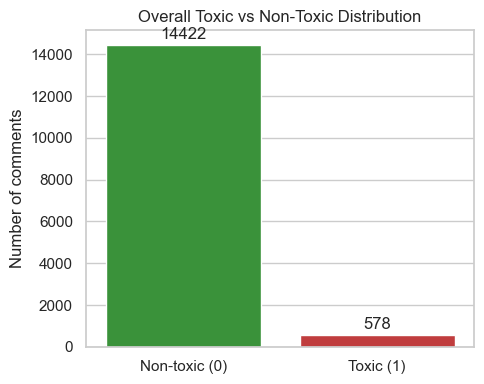

In [9]:
# Clean text and basic length features
df["comment_clean"] = df.get("Comment", "").astype(str).apply(clean_text)
df["comment_len"] = df["comment_clean"].str.split().apply(
    lambda tokens: len(tokens) if isinstance(tokens, list) else 0
)
df["comment_char_len"] = df["comment_clean"].str.len().fillna(0)

# Numeric columns
for col in ["comment_likes", "video_likes", "video_views", "video_comment_count"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.replace(-1, np.nan, inplace=True)

df.head()

# Lexicon-based labels
df["toxicity_label"] = label_toxicity_with_lexicon(df["comment_clean"])
print("\nToxic vs non-toxic (overall, based on lexicon):")
print(df["toxicity_label"].value_counts(normalize=True))

# Class balance plot
plot_class_balance(df["toxicity_label"], title="Overall Toxic vs Non-Toxic Distribution")

# Fill missing numeric values
for col in ["video_views", "video_likes", "video_comment_count"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

if "comment_likes" in df.columns:
    df["comment_likes"] = df["comment_likes"].fillna(0)

# Simple engagement features
df["likes_per_view"] = df["video_likes"] / (df["video_views"] + 1)
df["comment_like_ratio"] = df["comment_likes"] / (df["video_likes"] + 1)
df["engagement"] = (df["video_likes"] + df["video_comment_count"]) / (df["video_views"] + 1)

numeric_features = [
    "comment_likes",
    "video_likes",
    "video_views",
    "video_comment_count",
    "likes_per_view",
    "comment_like_ratio",
    "engagement",
    "comment_len",
    "comment_char_len",
]
numeric_features = [c for c in numeric_features if c in df.columns]

In [10]:
# Keep rows with clean text
df_model = df[df["comment_clean"].notna()].reset_index(drop=True)

X = df_model[["comment_clean"] + numeric_features]
y = df_model["toxicity_label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("\nTrain / test shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test : {X_test.shape}")
print("Label distribution in train:")
print(y_train.value_counts(normalize=True).to_dict())

TFIDF_MAX_FEATURES = 20000
SVD_DIM = 200

text_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=TFIDF_MAX_FEATURES,
                ngram_range=(1, 2),
                min_df=3,
                sublinear_tf=True,
            ),
        ),
        (
            "svd",
            TruncatedSVD(
                n_components=min(SVD_DIM, TFIDF_MAX_FEATURES - 1),
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_pipeline, "comment_clean"),
        ("num", numeric_pipeline, numeric_features),
    ]
)

print("\nFitting preprocessing pipelines...")
preprocessor.fit(X_train)

X_hybrid_train = preprocessor.transform(X_train)
X_hybrid_test = preprocessor.transform(X_test)

tfidf_for_lr = preprocessor.named_transformers_["text"].named_steps["tfidf"]
X_lr_train = tfidf_for_lr.transform(X_train["comment_clean"])
X_lr_test = tfidf_for_lr.transform(X_test["comment_clean"])


Train / test shapes:
  X_train: (12000, 10)
  X_test : (3000, 10)
Label distribution in train:
{0: 0.9615, 1: 0.0385}

Fitting preprocessing pipelines...



Training Logistic Regression (text only)...

Training Hybrid MLP (SVD + numeric features)...

Results for: LogReg_Text

Classification report:
              precision    recall  f1-score   support

           0     0.9969    0.9019    0.9470      2884
           1     0.2762    0.9310    0.4260       116

    accuracy                         0.9030      3000
   macro avg     0.6366    0.9165    0.6865      3000
weighted avg     0.9691    0.9030    0.9269      3000


Key metrics:
  CohenKappa: 0.3896
  Sensitivity_Recall_Toxic: 0.9310
  Specificity_Recall_NonToxic: 0.9019
  Precision_Toxic: 0.2762
  ROC_AUC: 0.9705
Saved figure: LogReg_Text_confusion_20251212_214651.png


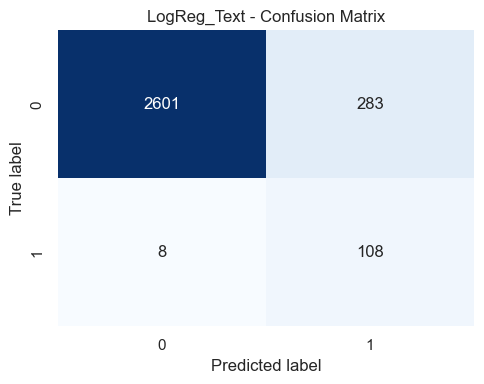

Saved figure: LogReg_Text_roccurve_20251212_214651.png


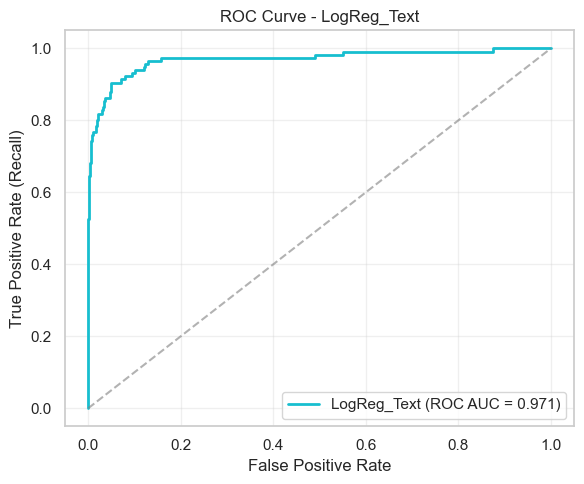


Results for: Hybrid_MLP

Classification report:
              precision    recall  f1-score   support

           0     0.9766    1.0000    0.9882      2884
           1     1.0000    0.4052    0.5767       116

    accuracy                         0.9770      3000
   macro avg     0.9883    0.7026    0.7824      3000
weighted avg     0.9775    0.9770    0.9723      3000


Key metrics:
  CohenKappa: 0.5670
  Sensitivity_Recall_Toxic: 0.4052
  Specificity_Recall_NonToxic: 1.0000
  Precision_Toxic: 1.0000
  ROC_AUC: 0.8868
Saved figure: Hybrid_MLP_confusion_20251212_214651.png


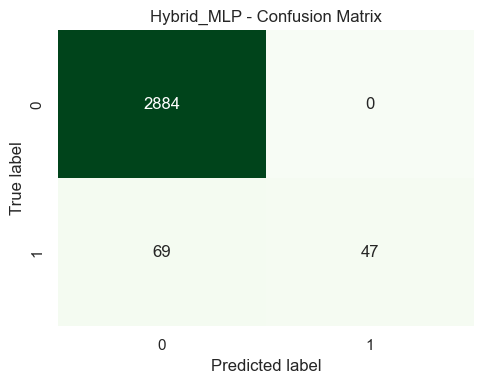

Saved figure: Hybrid_MLP_roccurve_20251212_214651.png


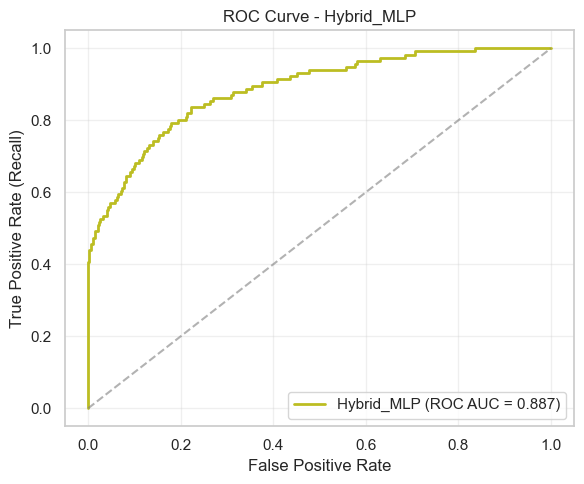

Saved figure: model_comparison_20251212_214651.png


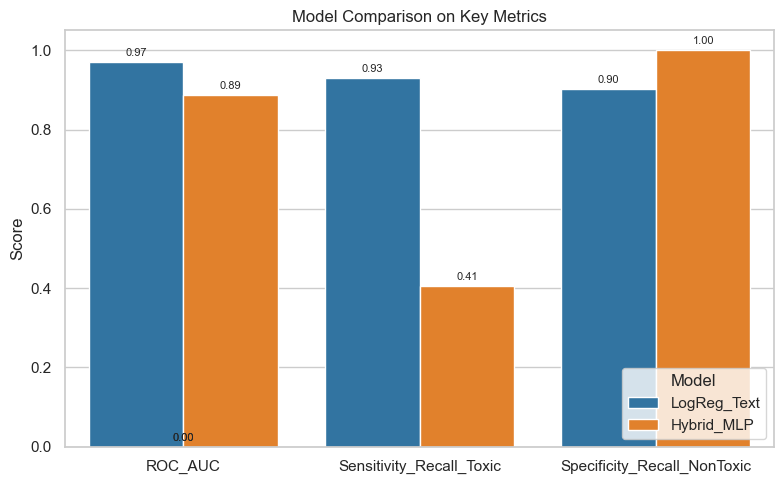

In [11]:
print("\nTraining Logistic Regression (text only)...")
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="saga",
    random_state=RANDOM_STATE,
)
lr_model.fit(X_lr_train, y_train)
y_lr_pred = lr_model.predict(X_lr_test)
y_lr_proba = lr_model.predict_proba(X_lr_test)[:, 1]


# Hybrid MLP (SVD + numeric features)
print("\nTraining Hybrid MLP (SVD + numeric features)...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    max_iter=500,
    early_stopping=True,
    random_state=RANDOM_STATE,
)
mlp_model.fit(X_hybrid_train, y_train)
y_mlp_pred = mlp_model.predict(X_hybrid_test)
y_mlp_proba = mlp_model.predict_proba(X_hybrid_test)[:, 1]

metrics_lr = evaluate_model(
    y_true=y_test,
    y_pred=y_lr_pred,
    y_proba=y_lr_proba,
    model_name="LogReg_Text",
)

metrics_mlp = evaluate_model(
    y_true=y_test,
    y_pred=y_mlp_pred,
    y_proba=y_mlp_proba,
    model_name="Hybrid_MLP",
)

plot_model_comparison(metrics_lr, metrics_mlp)


Creating word clouds from Logistic Regression coefficients...
Saved figure: wordcloud_toxic_nontoxic_20251212_214651.png


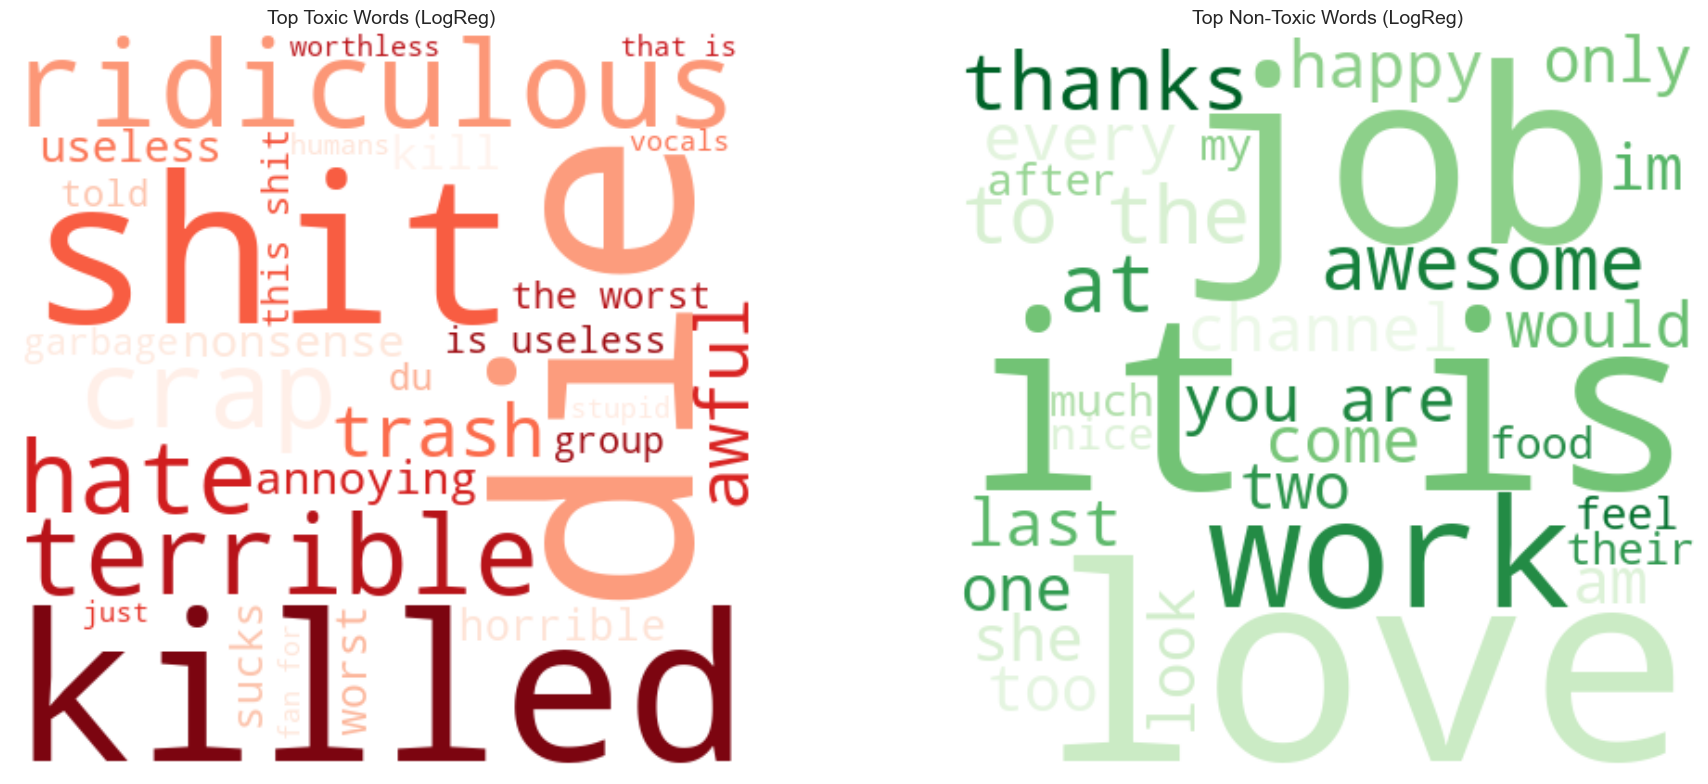

In [13]:
if WORDCLOUD_INSTALLED:
    print("\nCreating word clouds from Logistic Regression coefficients...")
    lr_coef = lr_model.coef_[0]
    feature_names = tfidf_for_lr.get_feature_names_out()
    sorted_idx = np.argsort(lr_coef)

    top_toxic = [(feature_names[i], lr_coef[i]) for i in sorted_idx[-30:]][::-1]
    top_nontoxic = [(feature_names[i], lr_coef[i]) for i in sorted_idx[:30]]

    top_n_words = 30
    toxic_dict = {word: coef for word, coef in top_toxic[:top_n_words]}
    nontoxic_dict = {word: -coef for word, coef in top_nontoxic[:top_n_words]}

    fig_wc, axes_wc = plt.subplots(1, 2, figsize=(20, 8))

    wc_toxic = WordCloud(
        width=400,
        height=400,
        background_color="white",
        colormap="Reds",
    ).generate_from_frequencies(toxic_dict)
    axes_wc[0].imshow(wc_toxic, interpolation="bilinear")
    axes_wc[0].axis("off")
    axes_wc[0].set_title("Top Toxic Words (LogReg)", fontsize=14)

    wc_nontoxic = WordCloud(
        width=400,
        height=400,
        background_color="white",
        colormap="Greens",
    ).generate_from_frequencies(nontoxic_dict)
    axes_wc[1].imshow(wc_nontoxic, interpolation="bilinear")
    axes_wc[1].axis("off")
    axes_wc[1].set_title("Top Non-Toxic Words (LogReg)", fontsize=14)

    for ax in axes_wc:
        ax.set_frame_on(True)
        ax.patch.set_edgecolor("black")
        ax.patch.set_linewidth(1)

    save_and_show(fig_wc, f"wordcloud_toxic_nontoxic_{TIMESTAMP}.png")
else:
    print("\nwordcloud not installed — skipping word cloud step.")


Computing SHAP explanations (this may take a bit)...
Saved figure: shap_lr_top_tokens_20251212_214651.png


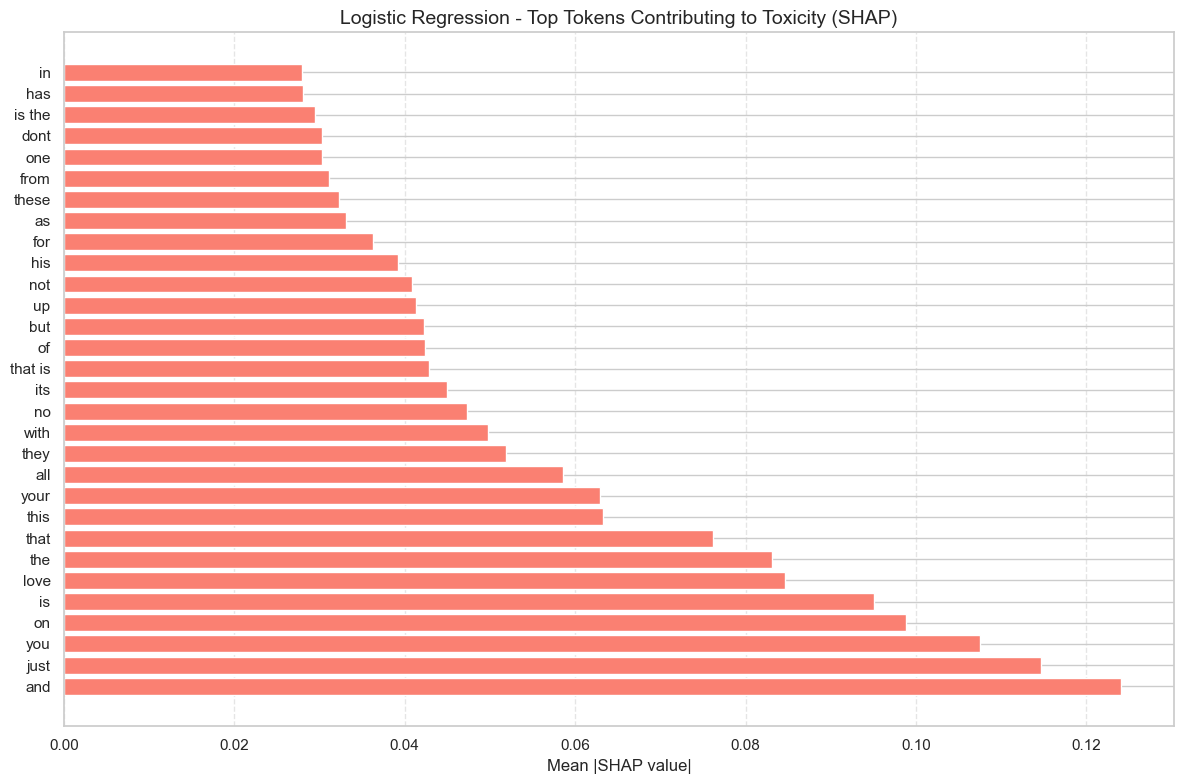

  0%|          | 0/50 [00:00<?, ?it/s]

Saved figure: shap_mlp_top_features_20251212_214651.png


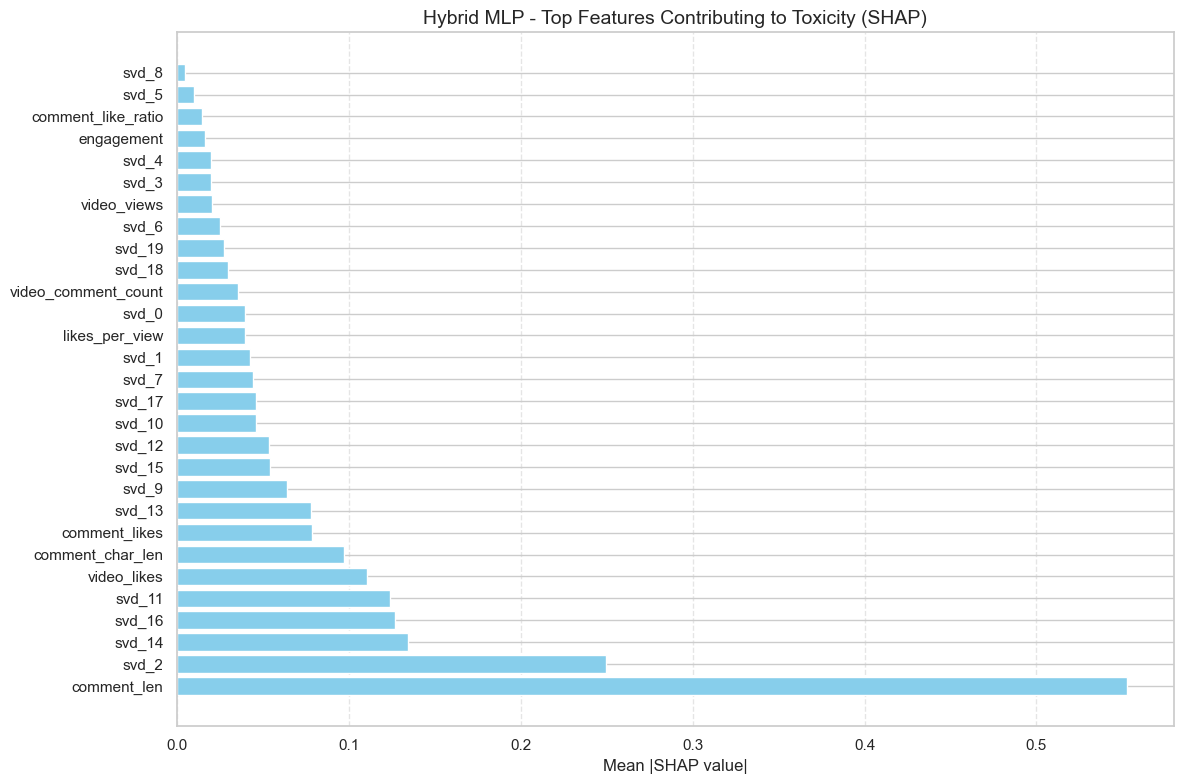

In [14]:
if SHAP_INSTALLED:
    try:
        print("\nComputing SHAP explanations (this may take a bit)...")

        # --- Logistic Regression SHAP ---
        bg_idx_lr = np.random.choice(
            X_lr_train.shape[0],
            size=min(200, X_lr_train.shape[0]),
            replace=False,
        )
        Xlr_bg = X_lr_train[bg_idx_lr].toarray() if hasattr(X_lr_train, "toarray") else X_lr_train[bg_idx_lr]

        expl_lr = shap.LinearExplainer(
            lr_model,
            Xlr_bg,
            feature_perturbation="interventional",
        )

        test_idx_lr = np.random.choice(
            X_lr_test.shape[0],
            size=min(200, X_lr_test.shape[0]),
            replace=False,
        )
        Xlr_test_small = X_lr_test[test_idx_lr].toarray() if hasattr(X_lr_test, "toarray") else X_lr_test[test_idx_lr]
        shap_vals_lr = expl_lr.shap_values(Xlr_test_small)

        shap_means_lr = np.abs(shap_vals_lr).mean(0)
        top_idx_lr = np.argsort(shap_means_lr)[-30:]
        top_tokens = feature_names[top_idx_lr]
        top_shap_vals = shap_means_lr[top_idx_lr]

        fig_shap_lr, ax_shap_lr = plt.subplots(figsize=(12, 8))
        ax_shap_lr.barh(top_tokens, top_shap_vals, color="salmon")
        ax_shap_lr.set_xlabel("Mean |SHAP value|", fontsize=12)
        ax_shap_lr.set_title("Logistic Regression - Top Tokens Contributing to Toxicity (SHAP)", fontsize=14,)
        ax_shap_lr.invert_yaxis()
        ax_shap_lr.grid(axis="x", linestyle="--", alpha=0.5)
        save_and_show(fig_shap_lr, f"shap_lr_top_tokens_{TIMESTAMP}.png")

        # --- Hybrid MLP SHAP ---
        n_svd_total = preprocessor.named_transformers_["text"].named_steps["svd"].n_components
        num_count = len(numeric_features)
        K = min(20, X_hybrid_train.shape[1])  # number of SVD dims we keep visible

        svd_idx = list(range(K))
        Xh_train_reduced = np.hstack(
            [X_hybrid_train[:, svd_idx], X_hybrid_train[:, n_svd_total : n_svd_total + num_count]]
        )
        Xh_test_reduced = np.hstack(
            [X_hybrid_test[:, svd_idx], X_hybrid_test[:, n_svd_total : n_svd_total + num_count]]
        )

        bg_idx_mlp = np.random.choice(
            Xh_train_reduced.shape[0],
            size=min(50, Xh_train_reduced.shape[0]),
            replace=False,
        )
        Xh_bg = Xh_train_reduced[bg_idx_mlp]

        def mlp_pred_reduced(x):
            x = np.atleast_2d(x)
            full = np.zeros((x.shape[0], X_hybrid_train.shape[1]))
            full[:, :K] = x[:, :K]
            full[:, n_svd_total : n_svd_total + num_count] = x[:, K : K + num_count]
            return mlp_model.predict_proba(full)[:, 1]

        expl_mlp = shap.KernelExplainer(
            mlp_pred_reduced,
            Xh_bg,
            link="logit",
        )

        test_idx_mlp = np.random.choice(
            Xh_test_reduced.shape[0],
            size=min(50, Xh_test_reduced.shape[0]),
            replace=False,
        )
        shap_vals_mlp = expl_mlp.shap_values(Xh_test_reduced[test_idx_mlp], nsamples=50)
        hybrid_feature_names = [f"svd_{i}" for i in range(K)] + numeric_features

        shap_means_mlp = np.abs(shap_vals_mlp).mean(0)
        top_idx_mlp = np.argsort(shap_means_mlp)[- (K + num_count) :]
        top_features = np.array(hybrid_feature_names)[top_idx_mlp]
        top_shap_vals_mlp = shap_means_mlp[top_idx_mlp]

        fig_shap_mlp, ax_shap_mlp = plt.subplots(figsize=(12, 8))
        ax_shap_mlp.barh(top_features, top_shap_vals_mlp, color="skyblue")
        ax_shap_mlp.set_xlabel("Mean |SHAP value|", fontsize=12)
        ax_shap_mlp.set_title(
            "Hybrid MLP - Top Features Contributing to Toxicity (SHAP)",
            fontsize=14,
        )
        ax_shap_mlp.invert_yaxis()
        ax_shap_mlp.grid(axis="x", linestyle="--", alpha=0.5)
        save_and_show(fig_shap_mlp, f"shap_mlp_top_features_{TIMESTAMP}.png")

    except Exception as e:
        print("\nSHAP failed with error:")
        print(e)
else:
    print("\nSHAP not installed — skipping explainability step.")